# APS 2026 Short Course Tutorial 1: Quantum Defect Embedding Theory (QDET)

This tutorial shows how to compute vertical excitation energies of the negatively charged nitrogen-vacancy center (NV$^-$) in diamond using quantum defect embedding theory (QDET). In QDET, the effective Hamiltonian that describes excitations within an active space consisting of selected Kohn-Sham (KS) orbitals is formulated as:

$$
H^{\text{eff}} = \sum_{ij}^A t^{\text{eff}}_{ij}\hat{a}_i^\dagger \hat{a}_j + \frac{1}{2} \sum_{ijkl}^A v^{\text{eff}}_{ijkl} \hat{a}_i^\dagger \hat{a}_j^\dagger \hat{a}_l \hat{a}_k,
$$

where $t^{\text{eff}}$ and $v^{\text{eff}}$ are the effective one- and two-body terms, respectively. An exact diagonalization of the effective Hamiltonian yields the energies and wavefunctions of the many-body states of the spin defect. More details about the method, and definitions for $t^{\text{eff}}$ and $v^{\text{eff}}$ can be found in [Sheng et al., J. Chem. Theory Comput. 18, 3512 (2022)](https://doi.org/10.1021/acs.jctc.2c00240) and [Chen et al., J. Chem. Theory Comput. 21, 7797 (2025)](https://doi.org/10.1021/acs.jctc.5c00559).

A QDET calculation is performed in four steps:

1. Perform a ground-state density functional theory (DFT) calculation.
2. Identify defect orbitals and define the active space.
3. Compute parameters $t^{\text{eff}}$ and $v^{\text{eff}}$ of the QDET effective Hamiltonian.
4. Diagonalize the Hamiltonian using full configuration interaction (FCI).

## 1. DFT

We perform a ground-state DFT calculation using [Quantum ESPRESSO](https://www.quantum-espresso.org/) (QE).

Download the following files to your working directory:

In [ ]:
%%bash
wget -N -q https://west-code.org/doc/training/nv_diamond_215/qdet/pw.in
wget -N -q http://www.quantum-simulation.org/potentials/sg15_oncv/upf/C_ONCV_PBE-1.2.upf
wget -N -q http://www.quantum-simulation.org/potentials/sg15_oncv/upf/N_ONCV_PBE-1.2.upf

The `pw.in` file is the input for the `pw.x` code:

In [1]:
%%bash
cat pw.in

! NV- in diamond 3x3x3 supercell
! V 0 0 0
&CONTROL
calculation = 'scf'
pseudo_dir = './'
/
&SYSTEM
ibrav = 0
ntyp = 2
nat = 215
tot_charge = -1.0
ecutwfc = 60.0
nbnd = 600
occupations = 'from_input'
/
&ELECTRONS
diago_full_acc = .true.
/
ATOMIC_SPECIES
C  12.011  C_ONCV_PBE-1.2.upf
N  14.007  N_ONCV_PBE-1.2.upf
CELL_PARAMETERS angstrom
10.704   0.000   0.000
 0.000  10.704   0.000
 0.000   0.000  10.704
K_POINTS gamma
ATOMIC_POSITIONS angstrom
N             0.9796932824        0.9796932824        0.9796932824
C             0.0434671029        1.7828522451        1.7828522451
C             0.8965358600        2.6900606190        2.6900606190
C             1.7828522451        0.0434671029        1.7828522451
C             2.6900606190        0.8965358600        2.6900606190
C             1.7828522451        1.7828522451        0.0434671029
C             2.6900606190        2.6900606190        0.8965358600
C             0.0009075481        0.0009075481        3.5625457860
C             0

We run `pw.x`.

In [ ]:
%%bash
mpirun -n 4 pw.x -i pw.in > pw.out

## 2. Compute localization factor and define QDET active space

We show how to identify KS orbitals that are localized in real space. We will compute the localization factor, defined as

$$
L_n = \int_{V \in \Omega} d^3\mathbf{r} \left| \psi^{\text{KS}}_n(\mathbf{r}) \right|^2
$$

It describes the localization of the n-th KS wavefunction in a given volume $V$ within the supercell $\Omega$. We use the `westpp.x` code to compute localization factors within a sphere. We create the input file `westpp.in`:

In [2]:
import yaml

d = {}
d["westpp_control"] = {}
d["westpp_control"]["westpp_calculation"] = "L"
d["westpp_control"]["westpp_range"] = [1, 600]
d["westpp_control"]["westpp_format"] = "S"
d["westpp_control"]["westpp_r0"] = [0, 0, 0]  # center of the vacancy (Bohr)
d["westpp_control"]["westpp_rmax"] = 3  # radius (Bohr) of a sphere enclosing atoms that are nearest neighbors of the vacancy

with open("westpp.in", "w") as f:
    yaml.dump(d, f, sort_keys=False)

The sphere is centered around the vacancy at $\left(0, 0, 0 \right)$ Bohr as specified by `westpp_r0`, and has a radius of 3 Bohr as specified by `westpp_rmax`.

In [3]:
%%bash
cat westpp.in

westpp_control:
  westpp_calculation: L
  westpp_range:
  - 1
  - 600
  westpp_format: S
  westpp_r0:
  - 0
  - 0
  - 0
  westpp_rmax: 3


We run `westpp.x`.

In [ ]:
%%bash
mpirun -n 4 westpp.x -i westpp.in > westpp.out

`westpp.x` creates a file named `west.westpp.save/westpp.json`. If the reader does NOT have the computational resources to run the calculation, the file needed for the next step can be downloaded as:

In [ ]:
%%bash
mkdir -p west.westpp.save
wget -N -q https://west-code.org/doc/training/nv_diamond_215/qdet/westpp.json -O west.westpp.save/westpp.json

We can now visualize the results:

Bands with the largest localization: [426 430 431 432]


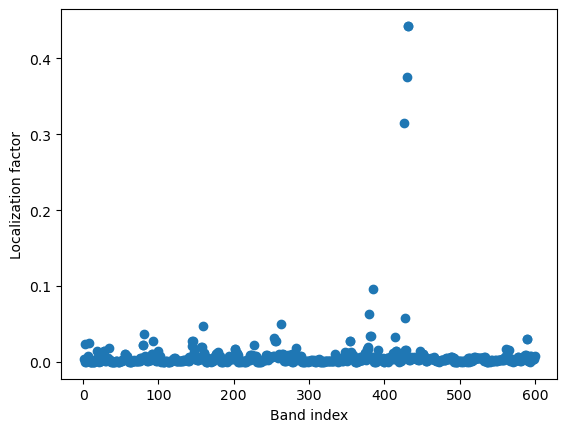

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open("west.westpp.save/westpp.json", "r") as f:
    data = json.load(f)

y = np.array(data["output"]["L"]["K000001"]["local_factor"])
x = np.array([i + 1 for i in range(y.shape[0])])

print("Bands with the largest localization:", x[y>=0.2])

plt.plot(x, y, "o")

plt.xlabel("Band index")
plt.ylabel("Localization factor")

plt.show()

The highest localization factors are obtained for bands 426, 430, 431, and 432, corresponding to the a$_1$ and e defect orbitals of the NV$^-$ center. These orbitals form the minimum model that describes the defect-to-defect excitations of the NV$^-$ center. The minimum model should be systematically expanded to assess the convergence of QDET calculations with respect to the size of the active space.

In the next step, we will use an active space consisting of the a$_1$ and e defect orbitals and all valence bands lying within 2 eV below the valence band maximum (VBM).

## 3. Build QDET effective Hamiltonian

We first use `wstat.x` to compute an eigendecomposition of the static dielectric screening, which is used as the basis set for the subsequent step. We then use `wfreq.x` to compute the partially screened Coulomb potential and the parameters of the effective Hamiltonian.

Download the following files to your working directory:

In [ ]:
%%bash
wget -N -q https://west-code.org/doc/training/nv_diamond_215/qdet/wstat.in
wget -N -q https://west-code.org/doc/training/nv_diamond_215/qdet/wfreq.in

We can have a look at the input files:

In [5]:
%%bash
cat wstat.in

input_west:
  outdir: ./

wstat_control:
  wstat_calculation: S
  n_pdep_eigen: 2586


The input keyword `n_pdep_eigen` controls the accuracy of the eigendecomposition of the static dielectric screening and should be carefully tested for convergence.

In [6]:
%%bash
cat wfreq.in

input_west:
  outdir: ./

wstat_control:
  wstat_calculation: S
  n_pdep_eigen: 2586

wfreq_control:
  wfreq_calculation: XWGQH
  macropol_calculation: C
  l_enable_off_diagonal: True
  n_pdep_eigen_to_use: 2586
  qp_bandrange: [414, 432]


The QDET calculation is triggered by the input keyword `wfreq_calculation: H` (for effective `H`amiltonian). The KS orbitals that define the active space are selected with `qp_bandrange` (in our case bands 414 to 432, corresponding to the defect orbitals and all valence bands lying within 2 eV below the VBM). It is mandatory to set `l_enable_off_diagonal: true`.

We run `wstat.x`, then `wfreq.x`.

In [ ]:
%%bash
mpirun -n 4 wstat.x -i wstat.in > wstat.out
mpirun -n 4 wfreq.x -i wfreq.in > wfreq.out

The parameters of the effective Hamiltonian are stored in a file named `west.wfreq.save/wfreq.json`. If the reader does NOT have the computational resources to run the calculation, the file needed for the next step can be downloaded as:

In [ ]:
%%bash
mkdir -p west.wfreq.save
wget -N -q https://west-code.org/doc/training/nv_diamond_215/qdet/wfreq.json -O west.wfreq.save/wfreq.json

## 4. Diagonalize QDET effective Hamiltonian

The effective Hamiltonian is diagonalized using the [WESTpy Python package](https://west-code.org/doc/westpy/latest/).

In [7]:
from westpy.qdet import QDETResult

effective_hamiltonian = QDETResult(filename="west.wfreq.save/wfreq.json")

# Diagonalize Hamiltonian using FCI
solution = effective_hamiltonian.solve()

 
 _    _ _____ _____ _____            
| |  | |  ___/  ___|_   _|           
| |  | | |__ \ `--.  | |_ __  _   _  
| |/\| |  __| `--. \ | | '_ \| | | | 
\  /\  / |___/\__/ / | | |_) | |_| | 
 \/  \/\____/\____/  \_/ .__/ \__, | 
                       | |     __/ | 
                       |_|    |___/  
 
WEST version     :  6.2.1
Today            :  2026-02-11 17:31:04.933041
Diagonalizing QDET effective Hamiltonian...
nspin: 1
occupations: [[2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1. 1.]]
solver: FCI


diag[1RDM - 1RDM(GS)]                                          \
  E [eV] char                   414   415   416    417    418    419    420   
0  0.000   3-                 0.000 0.000 0.000  0.000  0.000  0.000  0.000   
1  0.487   1-                -0.000 0.001 0.000  0.000  0.000 -0.000 -0.000   
2  0.488   1-                -0.000 0.000 0.001  0.000  0.000 -0.000  0.000   
3  1.408   1-                -0.000 0.002 0.002  0.000  0.000 -0.000 -0.000   
4  2.051   3-                -0.003 0.000 0.003  0.000 -0.000  0.000  0.000   
5  2.051   3-                -0.003 0.003 0.000 -0.000  0.000  0.000  0.000   
6  3.239   1-                -0.007 0.001 0.003  0.000  0.000 -0.000 -0.000   
7  3.240   1-                -0.007 0.003 0.001  0.000  0.000 -0.000 -0.000   
8  4.872   1-                -0.005 0.003 0.003 -0.000 -0.000 -0.000 -0.000   
9  5.129   3-                -0.016 0.000 0.003  0.000  0.000  0.000  0.000   

          ...                                                               \
     421  ...    423    424    425    426    427   428   429    430    431   
0  0.000  ...  0.000  0.000  0.000  0.000  0.000 0.000 0.000  0.000  0.000   
1 -0.000  ... -0.000  0.000  0.000 -0.013 -0.008 0.002 0.001 -0.082 -0.000   
2 -0.000  ... -0.000  0.000  0.000 -0.013 -0.008 0.001 0.002 -0.082  0.101   
3  0.000  ...  0.000  0.000  0.000 -0.023 -0.011 0.003 0.003 -0.086  0.054   
4  0.000  ...  0.000  0.000  0.000 -0.035 -0.063 0.000 0.007 -0.898  0.989   
5 -0.000  ...  0.000  0.000  0.000 -0.035 -0.063 0.007 0.000 -0.898  0.000   
6 -0.000  ...  0.000  0.000 -0.000 -0.013 -0.026 0.002 0.007 -0.871  0.907   
7 -0.000  ...  0.000 -0.000  0.000 -0.013 -0.026 0.007 0.002 -0.871 -0.003   
8 -0.000  ...  0.000 -0.000 -0.000 -0.081 -0.101 0.006 0.006 -1.707  0.937   
9 -0.000  ... -0.000 -0.000 -0.000 -0.880 -0.048 0.000 0.007 -0.056  0.989   

          
     432  
0  0.000  
1  0.100  
2 -0.001  
3  0.055  
4  0.000  
5  0.989  
6 -0.003  
7  0.907  
8  0.937  
9  0.001  

[10 rows x 21 columns]

Calling the `solve` method of `QDETResult` invokes the FCI module in PySCF to diagonalize the QDET Hamiltonian. The vertical excitation energies (in eV), spin multiplicity, and electron occupation (relative to the ground state) are written to the screen.

The first excited state has an energy of 0.487 eV above the ground state, has spin multiplicity 2S + 1 = 1 (i.e., it is a singlet), and is two-fold degenerate, as the second excited state has the same energy. These are the $^1$E singlet excited states of the NV$^-$ center. The next excited state at 1.408 eV is the $^1$A$_1$ singlet excited state. The next pair of excited states at 2.051 eV are the $^3$E triplet excited states.

The symmetry of the excited states can be automatically identified using the point symmetry of the defect. In order to perform the symmetry analysis, we use `westpp.x` to write the KS wavefunctions to cube files. Create the input file `westpp.in`:

In [8]:
import yaml

d = {}
d["westpp_control"] = {}
d["westpp_control"]["westpp_calculation"] = "W"
d["westpp_control"]["westpp_range"] = [1, 600]
d["westpp_control"]["westpp_format"] = "C"
d["westpp_control"]["westpp_sign"] = True

with open("westpp.in", "w") as f:
    yaml.dump(d, f, sort_keys=False)

In [9]:
%%bash
cat westpp.in

westpp_control:
  westpp_calculation: W
  westpp_range:
  - 1
  - 600
  westpp_format: C
  westpp_sign: true


We run `westpp.x`.

In [ ]:
%%bash
mpirun -n 4 westpp.x -i westpp.in > westpp.out

The cube files of the wavefunctions are stored in a folder named `west.westpp.save`. The files are large and therefore not provided for readers who do not have the computational resources to run the calculations.

Now we define the point group, characterized by:

- a set of symmetry operations (identity, reflection, and rotation operations)
- a corresponding character table

In [10]:
import numpy as np
from westpy.qdet.symm import PointGroup, PointGroupOperation, PointGroupRotation, PointGroupReflection

sq3 = np.sqrt(3)

origin = np.array([0, 0, 0])

point_group = PointGroup(
    name="C3v",
    operations={
        "E": PointGroupOperation(T=np.eye(4)),
        "C3_1": PointGroupRotation(rotvec=2 * np.pi / 3 * np.array([1 / sq3, 1 / sq3, 1 / sq3]), origin=origin),
        "C3_2": PointGroupRotation(rotvec=4 * np.pi / 3 * np.array([1 / sq3, 1 / sq3, 1 / sq3]), origin=origin),
        "Cv_1": PointGroupReflection(normal=(1, -1, 0), origin=origin),
        "Cv_2": PointGroupReflection(normal=(0, -1, 1), origin=origin),
        "Cv_3": PointGroupReflection(normal=(-1, 0, 1), origin=origin),
    },
    ctable={
        "A1": [1, 1, 1, 1, 1, 1],
        "A2": [1, 1, 1, -1, -1, -1],
        "E": [2, -1, -1, 0, 0, 0]},
)

To add point group analysis to QDET, we pass the point group object defined above to the Hamiltonian object. Additionally, we provide the list of KS wavefunctions in cube files.

The code will apply the symmetry operations to the wavefunctions and determine the character of the wavefunctions. After the diagonalization of the effective Hamiltonian, the character of the many-body states can then be inferred from the character of the wavefunctions.

In [11]:
from westpy.qdet import QDETResult

# List of cube files for the wavefunctions
qp_bands = list(range(414, 433))
wfc_names = [f"west.westpp.save/wfcK000001B{ib:06d}.cube" for ib in qp_bands]

effective_hamiltonian = QDETResult(filename="west.wfreq.save/wfreq.json", point_group=point_group, wfct_filenames=wfc_names)

# Diagonalize Hamiltonian using FCI
solution = effective_hamiltonian.solve()

PointGroupRep: rep matrices are orthogonal
Irrep of orbitals: ['A1(1.00)', 'E(1.00)', 'E(1.00)', 'E(1.00)', 'E(1.00)', 'A2(1.00)', 'A2(1.00)', 'E(1.00)', 'E(1.00)', 'A2(1.00)', 'E(1.00)', 'E(1.00)', 'A1(1.00)', 'A1(1.00)', 'E(1.00)', 'E(1.00)', 'A1(1.00)', 'E(1.00)', 'E(1.00)']
Solutions are projected onto irreps of C3v group
Diagonalizing QDET effective Hamiltonian...
nspin: 1
occupations: [[2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 1. 1.]]
solver: FCI


diag[1RDM - 1RDM(GS)]                                          \
  E [eV] char                   414   415   416    417    418    419    420   
0  0.000  3A2                 0.000 0.000 0.000  0.000  0.000  0.000  0.000   
1  0.487   1E                -0.000 0.001 0.000  0.000  0.000 -0.000 -0.000   
2  0.488   1E                -0.000 0.000 0.001  0.000  0.000 -0.000  0.000   
3  1.408  1A1                -0.000 0.002 0.002  0.000  0.000 -0.000 -0.000   
4  2.051   3E                -0.003 0.000 0.003  0.000 -0.000  0.000  0.000   
5  2.051   3E                -0.003 0.003 0.000 -0.000  0.000  0.000  0.000   
6  3.239   1E                -0.007 0.001 0.003  0.000  0.000 -0.000 -0.000   
7  3.240   1E                -0.007 0.003 0.001  0.000  0.000 -0.000 -0.000   
8  4.872  1A1                -0.005 0.003 0.003 -0.000 -0.000 -0.000 -0.000   
9  5.129   3E                -0.016 0.000 0.003  0.000  0.000  0.000  0.000   

          ...                                                               \
     421  ...    423    424    425    426    427   428   429    430    431   
0  0.000  ...  0.000  0.000  0.000  0.000  0.000 0.000 0.000  0.000  0.000   
1 -0.000  ... -0.000  0.000  0.000 -0.013 -0.008 0.002 0.001 -0.082 -0.000   
2 -0.000  ... -0.000  0.000  0.000 -0.013 -0.008 0.001 0.002 -0.082  0.101   
3  0.000  ...  0.000  0.000  0.000 -0.023 -0.011 0.003 0.003 -0.086  0.054   
4  0.000  ...  0.000  0.000  0.000 -0.035 -0.063 0.000 0.007 -0.898  0.989   
5 -0.000  ...  0.000  0.000  0.000 -0.035 -0.063 0.007 0.000 -0.898  0.000   
6 -0.000  ...  0.000  0.000 -0.000 -0.013 -0.026 0.002 0.007 -0.871  0.907   
7 -0.000  ...  0.000 -0.000  0.000 -0.013 -0.026 0.007 0.002 -0.871 -0.003   
8 -0.000  ...  0.000 -0.000 -0.000 -0.081 -0.101 0.006 0.006 -1.707  0.937   
9 -0.000  ... -0.000 -0.000 -0.000 -0.880 -0.048 0.000 0.007 -0.056  0.989   

          
     432  
0  0.000  
1  0.100  
2 -0.001  
3  0.055  
4  0.000  
5  0.989  
6 -0.003  
7  0.907  
8  0.937  
9  0.001  

[10 rows x 21 columns]

The symmetry of the ground state $^3$A$_2$, singlet excited states $^1$E and $^1$A$_1$, and triplet excited states $^3$E are identified correctly.